✅ Loaded df_base (4,000,000 rows)
✅ Loaded df_rep  (3,012,000 rows)
Detected genes: ['gene_1', 'gene_2']


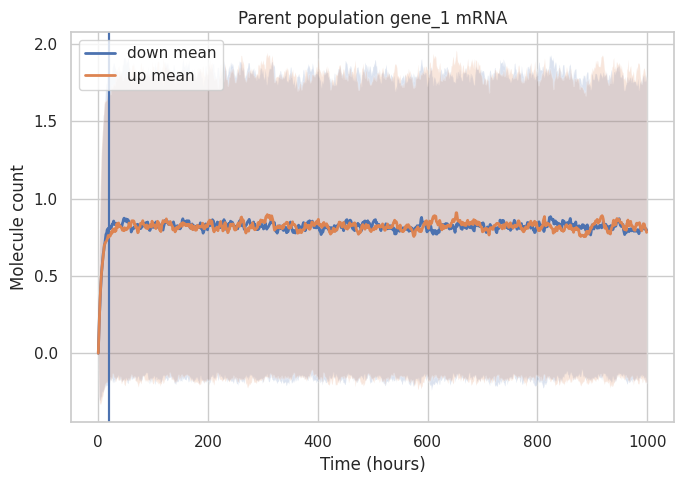

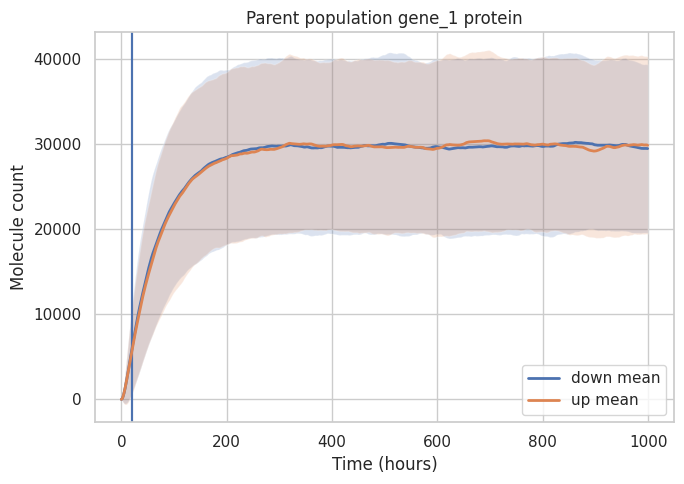

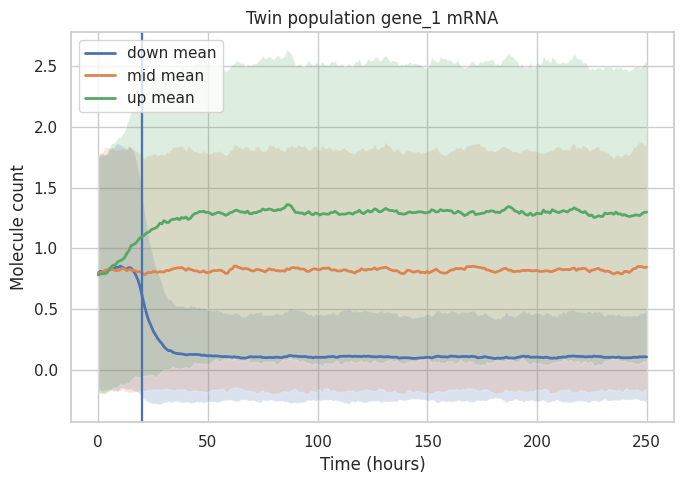

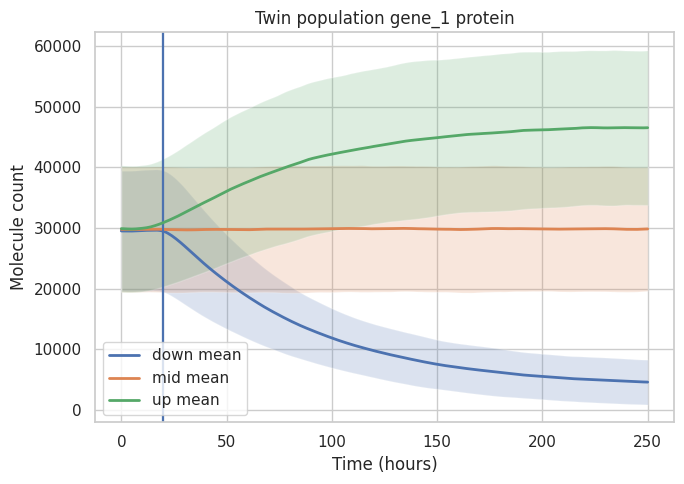

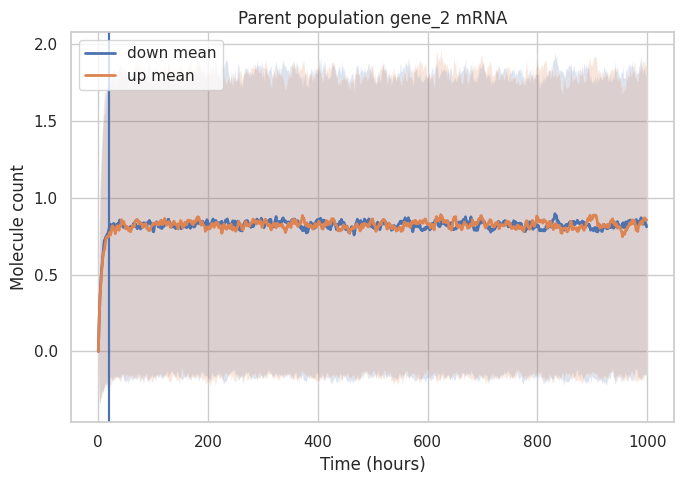

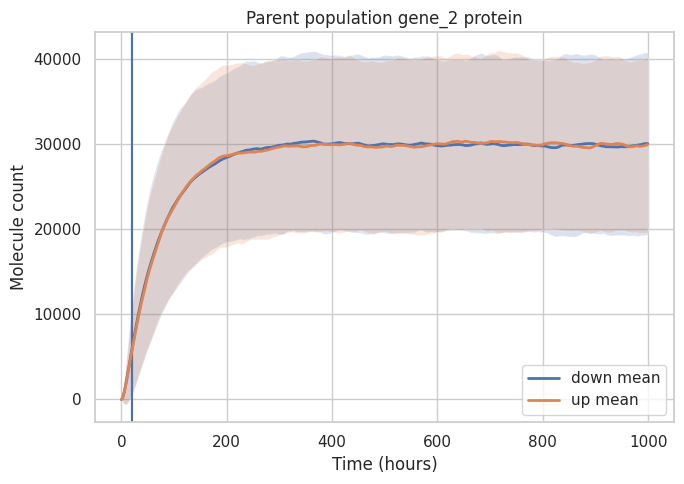

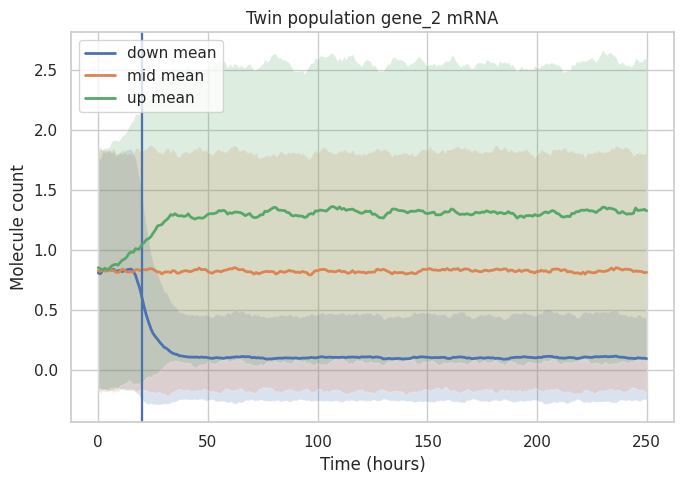

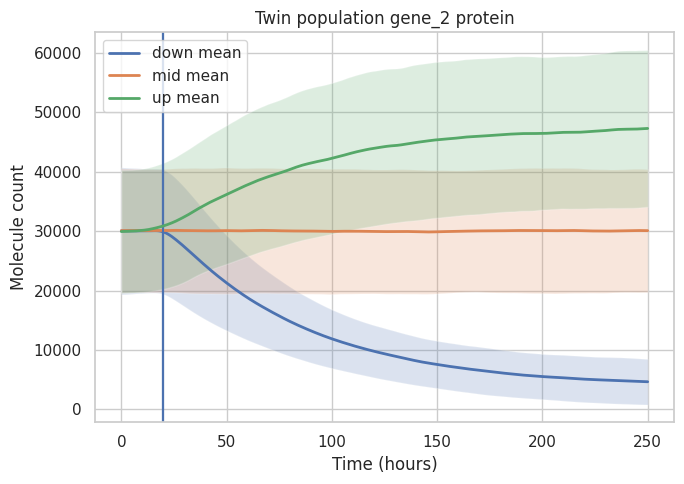

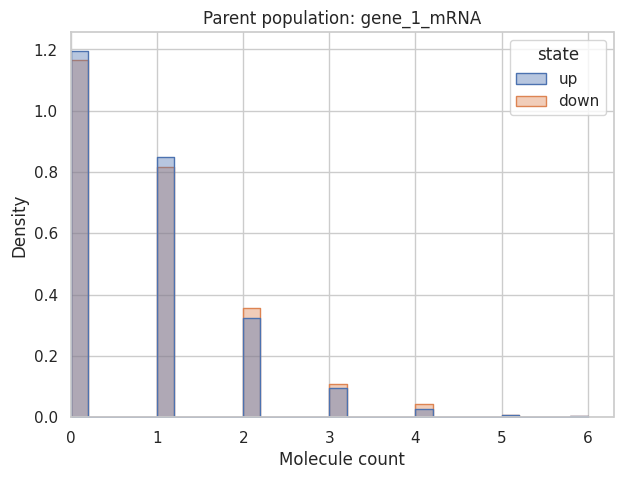

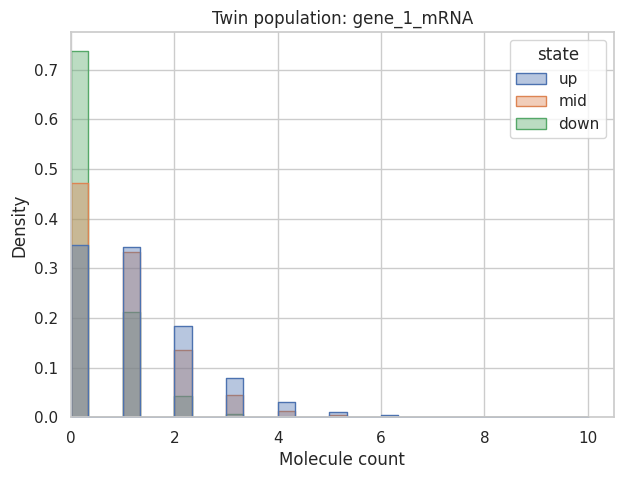

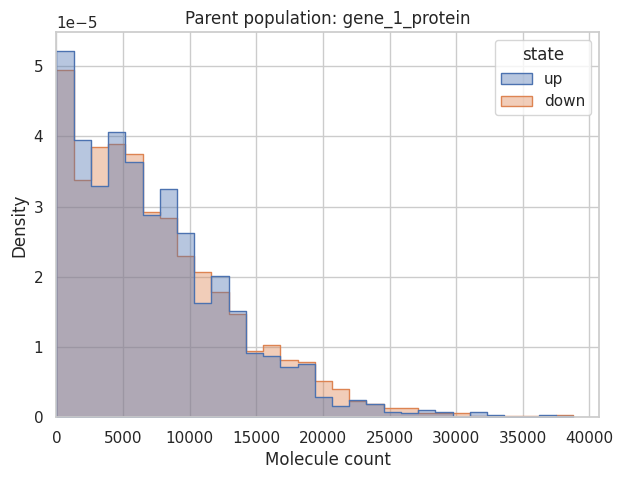

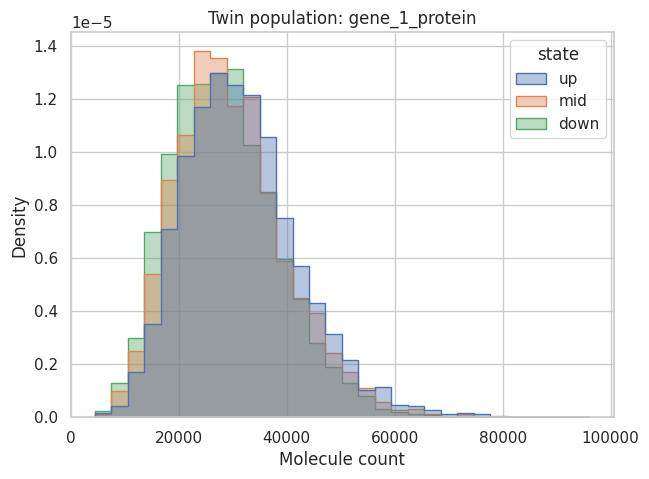

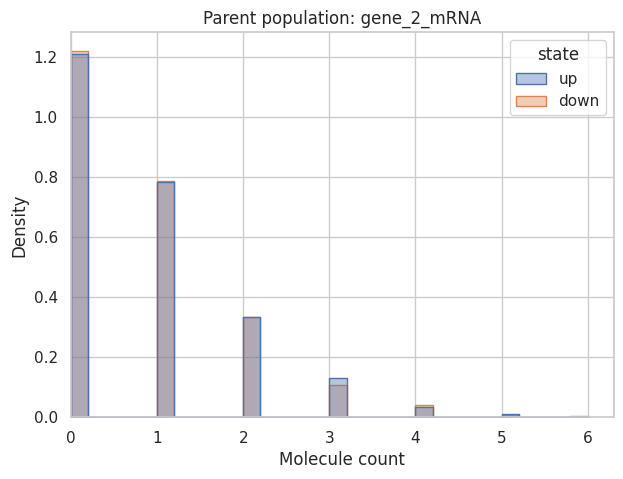

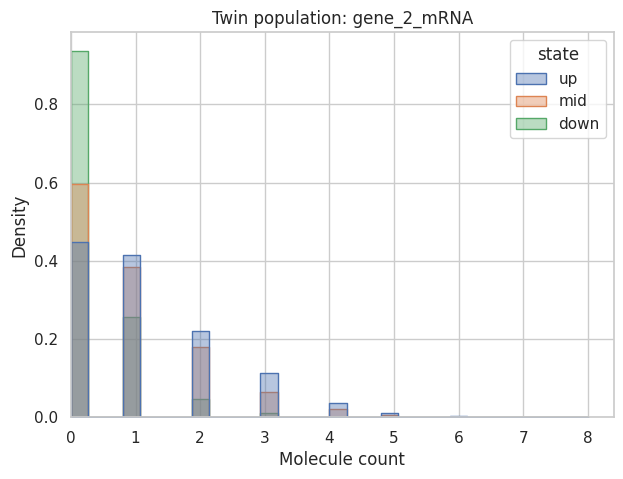

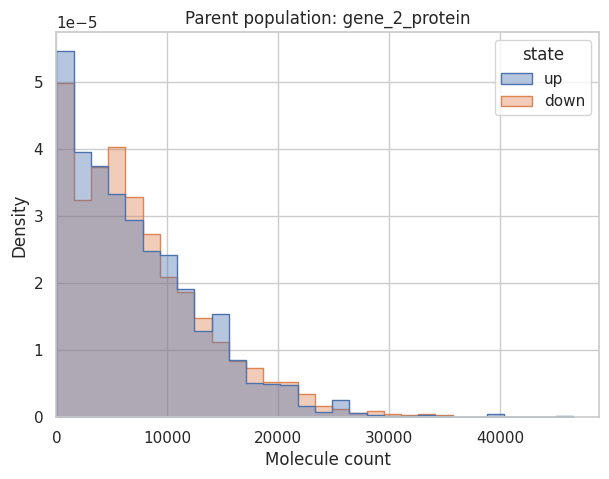

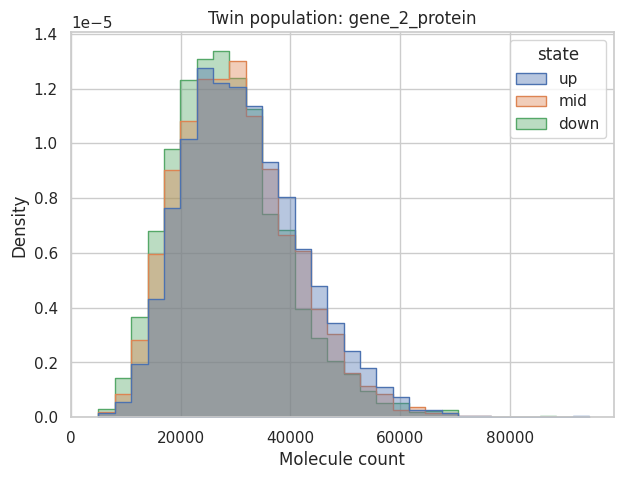

In [4]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === CONFIGURATION ===
twin_csv = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/drift_simulation/drift_simulation_15_h_3_states/df_rows_0_1_31102025_014912_ncells_6000_3_states_no_reg_different_timing_4cdb07f9.csv")
base_csv = Path("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/drift_simulation/drift_simulation_15_h_3_states/simulation_before_division_df_rows_0_1_31102025_014912_ncells_6000_3_states_no_reg_different_timing_4cdb07f9.csv")

# %%
# === LOAD ===
df_base = pd.read_csv(base_csv)
df_rep = pd.read_csv(twin_csv)
print(f"✅ Loaded df_base ({len(df_base):,} rows)")
print(f"✅ Loaded df_rep  ({len(df_rep):,} rows)")

# Sanity check for state column
if "state" not in df_rep.columns:
    raise ValueError("No 'state' column found in df_rep — did you add it in process_param_set()?")

# Infer states for df_base if missing (optional)
if "state" not in df_base.columns:
    n_cells_half = df_rep["clone_id"].nunique() // 2
    df_base["state"] = ["up"] * n_cells_half + ["down"] * n_cells_half

# %%
# === DETECT GENES ===
mrna_cols = [c for c in df_rep.columns if c.endswith("_mRNA")]
protein_cols = [c for c in df_rep.columns if c.endswith("_protein")]
genes = sorted({c.split("_")[0] + "_" + c.split("_")[1] for c in protein_cols})
print(f"Detected genes: {genes}")

# %%
def plot_state_dynamics(df, gene, kind="protein", title_prefix=""):
    """
    Plot mean ± SD over time for 'up' and 'down' states for a given gene.
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.set(style="whitegrid")
    for state, subdf in df.groupby("state"):
        cols = [c for c in subdf.columns if c.endswith(f"{gene}_{kind}")]
        if not cols:
            continue
        plt.axvline(20)
        grouped = subdf.groupby("time_step")[cols]
        mean = grouped.mean().values.flatten()
        std = grouped.std().values.flatten()
        times = grouped.mean().index
        ax.plot(times, mean, label=f"{state} mean", lw=2)
        ax.fill_between(times, mean - std, mean + std, alpha=0.2)
    ax.set_title(f"{title_prefix} {gene} {kind}")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Molecule count")
    ax.legend()
    plt.tight_layout()
    plt.show()

# %%
# === PLOT PARENT POPULATION (df_base) ===
gene_to_plot = "gene_1"
plot_state_dynamics(df_base, gene_to_plot, "mRNA", "Parent population")
plot_state_dynamics(df_base, gene_to_plot, "protein", "Parent population")

# %%
# === PLOT TWIN POPULATION (df_rep) ===
plot_state_dynamics(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_state_dynamics(df_rep, gene_to_plot, "protein", "Twin population")

# === PLOT PARENT POPULATION (df_base) ===
gene_to_plot = "gene_2"
plot_state_dynamics(df_base, gene_to_plot, "mRNA", "Parent population")
plot_state_dynamics(df_base, gene_to_plot, "protein", "Parent population")

# %%
# === PLOT TWIN POPULATION (df_rep) ===
plot_state_dynamics(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_state_dynamics(df_rep, gene_to_plot, "protein", "Twin population")

# %%
# === COMPARE FINAL DISTRIBUTIONS ===
def plot_final_distribution_by_state(df, gene, kind="protein", title="Final distribution"):
    import seaborn as sns
    import matplotlib.pyplot as plt

    t_max = 25
    col = f"{gene}_{kind}"

    plt.figure(figsize=(7,5))
    sns.histplot(
        data=df[df["time_step"] == t_max],
        x=col,
        hue="state",
        bins=30,                # adjust number of bins as needed
        multiple="layer",       # or "dodge" to see side-by-side bars
        stat="density",         # normalizes area to 1
        fill=True,
        alpha=0.4,
        element="step"          # outlines instead of solid bars
    )
    
    plt.title(f"{title}: {col}")
    plt.xlabel("Molecule count")
    plt.xlim(left=0)
    plt.show()

gene_to_plot = "gene_1"
plot_final_distribution_by_state(df_base, gene_to_plot, "mRNA", "Parent population")
plot_final_distribution_by_state(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_final_distribution_by_state(df_base, gene_to_plot, "protein", "Parent population")
plot_final_distribution_by_state(df_rep, gene_to_plot, "protein", "Twin population")
gene_to_plot = "gene_2"
plot_final_distribution_by_state(df_base, gene_to_plot, "mRNA", "Parent population")
plot_final_distribution_by_state(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_final_distribution_by_state(df_base, gene_to_plot, "protein", "Parent population")
plot_final_distribution_by_state(df_rep, gene_to_plot, "protein", "Twin population")


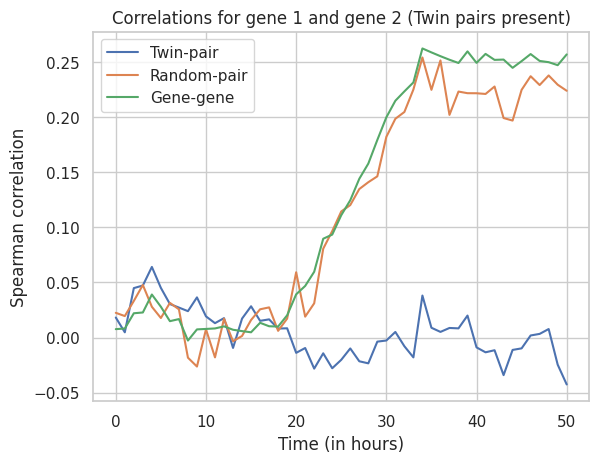

In [3]:
from scipy.stats import spearmanr
time_points = df_rep[df_rep['time_step']<51]['time_step'].unique()
n_genes = 2

gene_list = [f"gene_{i}" for i in range(1, n_genes + 1)]
columns_interest = [f"{gene}_mRNA" for gene in gene_list]
corr_list = []
rand_corr_list = []
gene_corr = []
# ----- Step 1: Compute correlations -----
def calculate_correlation(rep_0, rep_1):
    correlations = {}
    for gene_1 in gene_list:
        for gene_2 in gene_list:
            delta_1 = rep_0[f"{gene_1}_mRNA"] - rep_1[f"{gene_1}_mRNA"]
            delta_2 = rep_0[f"{gene_2}_mRNA"] - rep_1[f"{gene_2}_mRNA"]
            corr = spearmanr(delta_1, delta_2).correlation
            correlations[f"{gene_1}-{gene_2}"] = corr
    return correlations

# ----- Step 2: Convert to matrix -----
def dict_to_matrix(correlation_dict, gene_list):
    matrix = pd.DataFrame(index=gene_list, columns=gene_list, dtype=float)
    for key, value in correlation_dict.items():
        g1, g2 = key.split("-")
        matrix.loc[g1, g2] = value
    return matrix
clone_id = pd.Series(df_rep['clone_id'].unique()).sample(frac=0.5, random_state=42)

for time in time_points:
    # if time > 1500:
    #     continue
    # Assume updated_df is already defined and contains 'replicate', 'timestep', and mRNA columns
    singleTime_df = df_rep[df_rep['time_step'] == time]
    singleTime_df = singleTime_df[singleTime_df['clone_id'].isin(clone_id)]
    gene_gene_corr = spearmanr(singleTime_df['gene_1_mRNA'], singleTime_df['gene_2_mRNA']).correlation
    # Split into replicates
    rep_0_t1 = singleTime_df[singleTime_df['replicate'] == 1].reset_index(drop=True)
    rep_1_t1 = singleTime_df[singleTime_df['replicate'] == 2].reset_index(drop=True)
    rep_shuffled_t1 = rep_1_t1.sample(frac = 1).reset_index(drop=True)


    # Compute correlation matrix
    correlation_dict = calculate_correlation(rep_0_t1, rep_1_t1)
    corr_rand_dict = calculate_correlation(rep_0_t1, rep_shuffled_t1)
    corr_list.append(correlation_dict['gene_1-gene_2'])
    rand_corr_list.append(corr_rand_dict['gene_1-gene_2'])
    gene_corr.append(gene_gene_corr)

plt.title("Correlations for gene 1 and gene 2 (Twin pairs present)")
plt.plot(time_points, corr_list, label = "Twin-pair")
plt.plot(time_points, rand_corr_list, label = "Random-pair")
plt.plot(time_points, gene_corr, label="Gene-gene")
plt.xlabel('Time (in hours)')
plt.ylabel('Spearman correlation')
# plt.axhline(0.01, linestyle = "--",  color = "red",label = "twin threshold")
# plt.axhline(-0.01, linestyle = "--",  color = "red",)

# plt.axhline(0.05, linestyle = "--", color = "blue", label = "gene-gene threshold")
# plt.axhline(-0.05, linestyle = "--", color = "blue",)
plt.legend()
plt.show()
